# Welcome to Python for Data Science!
Today we'll exploring the world of Pandas. We will be using a timeseries dataset from the UCI Machine Learning repository to learn to how to wrangle data and perform analysis. In the second half of the day you'll do some feature engineering and finally there will be room to build a small model to actually put your features to use!

<img src="https://miro.medium.com/max/1400/1*1oVjIRY3Bnmbw-idCtg4BQ@2x.jpeg" style="width: 60%;"/>

## In this part we'll cover the following topics:
- Data ingestion
- Data cleaning
- Data exploration (specifically timeseries) 
- Storing your data (you'll need it in the next part). 

## Getting started
First things first, import the following libraries: `pandas`, `matplotlib` and `numpy`

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

---

# Ingestion
The first step in the data science process is data collection. In this section we'll load in some data. Information about the dataset that we'll be loading is located [here](https://archive.ics.uci.edu/ml/datasets/individual+household+electric+power+consumption)
- Load the power consumption dataset from the data folder
- Inspect the top 5 rows
- Check the data types of the dataframe and answer the following questions:
    - What's wrong with the data types in the info panel?
    - What data types would you expect for each column?
    - Does it make sense to have date and time columns separated?
    

In [59]:
# Load data
data = pd.read_csv('data/household_power_consumption.csv', delimiter=';', na_values='?')

In [60]:
# Inspect top 5
data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [61]:
# Inspect data types. Date and time are strings. 
# If you didn't use na_values on read, you'll find more "object" columns here.
data.dtypes

Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

---

# Data cleaning
In this section you're going to do some data cleaning. Since this is a timeseries dataset, you'll need to make it more usable before we can continue.
- Add date and time columns together and make a single datetime variable. Verify that your new column has the right data type and is correct. The result should be a datetime64\[ns\] object.
- Remove the date and time column from the dataset. 
- Have a look at our variable of interest; `Global_active_power`
    - What data type was assigned by pandas to this variable? Does this make sense?
    - Try casing the variable to the right data type, what do you see?
    - Can you explain this behaviour?
    - Fix the way you load data and rerun your code
    - What change occurred with the data types?
- If you read the dataset description in the previous step, it seems that we can construct a column with the total energy consumption based on the columns that are available. Do this and name this column `power`. 

    

In [62]:
# Stitch columns together and cast to datetime
data = data.assign(
    datetime=pd.to_datetime(
        (data['Date'] + 'T' + data['Time']), format='%d/%m/%YT%H:%M:%S')
)

In [63]:
# Drop date and time
data = data.drop(['Date', 'Time'], axis=1)

In [64]:
# Variable of interest
data['Global_active_power'].dtype

# If you didn't use na_values on read, you get a problem casting to float since the column contains string values.

# You can fix this by dealing with the manual entries/missing values

# Pandas will then cast the column to the right data type (float64)

dtype('float64')

In [65]:
# Use UCI logic to compute the power column
data = data.assign(
    power = lambda df: df.Global_active_power * 1000 / 60 - df.Sub_metering_1 - df.Sub_metering_2 - df.Sub_metering_3
)

## Missing values
Find out if there are weird of missing values in the data. Try to identify the rows and columns and answer the following questions.
- are there any missing values in the data set?
- if so, which column(s) contain missing values?
- if there are any missing values, extract the rows and the number of rows that contain missing values
- What would be a good way to deal with the missing values?
- Use your prefered approach to deal with the missing values. Validate if there are any missing values left in your data 

In [66]:
# We can use isna() and .any() to aggregate results. 
data.isna().any()

Global_active_power       True
Global_reactive_power     True
Voltage                   True
Global_intensity          True
Sub_metering_1            True
Sub_metering_2            True
Sub_metering_3            True
datetime                 False
power                     True
dtype: bool

In [67]:
# We can change the orientation to rows to obtain the rows with NA's
# Try to execute the commands between brackets first, to see what happens.
data.loc[data.isna().any(axis=1)]

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime,power
6839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:23:00,NaN
6840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:24:00,NaN
19724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:08:00,NaN
19725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:09:00,NaN
41832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-01-14 18:36:00,NaN
...,...,...,...,...,...,...,...,...,...
1990185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-09-28 19:09:00,NaN
1990186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-09-28 19:10:00,NaN
1990187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-09-28 19:11:00,NaN
1990188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-09-28 19:12:00,NaN


In [68]:
# Since the observations are on minute level, and the data is a timeseries, forward fill might be suitable for 
# filling the missing values. Alternatively, you can use other techniques, such as a linear model, mean filling or
# dropping.


data = data.fillna(method='ffill') # OR data.dropna(axis=1, how='any')

---

# Creating a timeseries
In this section we'll combine some data wrangling with data exploration. 
- The data contains a timeseries, however the current index of the dataframe does not really show this. Change the index to our newly created datetime column so that we end up with a datetime index.

In [69]:
# Use set_index
data = data.set_index(data['datetime'])

## Plotting
- Having a dataframe with a timeseries index allows us to some funky tricks 
    - Plot the `power` column, is this useful?
    - Create the same plot on the following aggregation levels:
        - Mean per year
        - Mean per 3 months
        - Mean per week
        - Mean per week and median per week
    - Explore the use of `transform` on resampled data. What is the difference with running a normal aggregation function such as `.mean()` on resampled data? Show the differences below.
    - When would you `transform`?    
    - *Optional*: Explore the `seaborn` package. You can import this and make some nicer plots. 

<AxesSubplot:xlabel='datetime'>

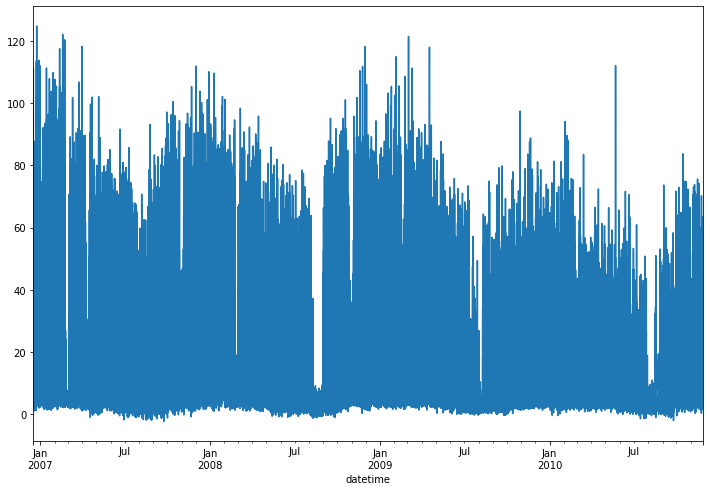

In [25]:
# Plot the energy consumption
data['power'].plot(figsize=(12,8))

# Not really too useful, can see some patterns on first sight but it's slow.

<AxesSubplot:xlabel='datetime'>

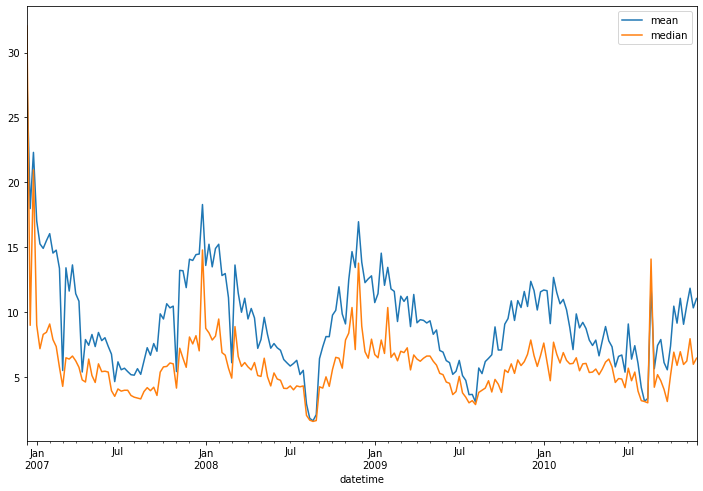

In [84]:
# 7 day mean and median. Change the resample period accordingly for each subquestion
data['power'].resample('W').agg(['mean', 'median']).plot(figsize=(12,8))

<AxesSubplot:xlabel='datetime'>

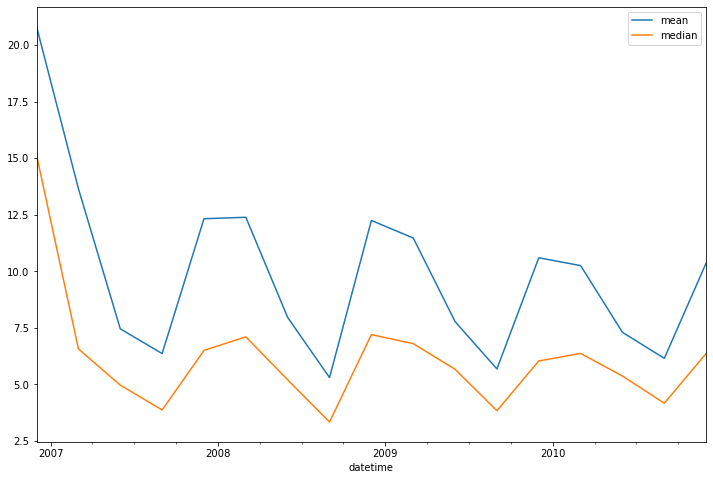

In [27]:
# 3 month mean and median
data['power'].resample('3M').agg(['mean', 'median']).plot(figsize=(12,8))

In [38]:
# Transform keeps the original granularity, it's comparable to a window function vs group by in SQL.
data['power'].resample('M').transform(np.mean)

# You can use this to add information to your data on the current level without 
# reducing the number of records or throwing away information.

datetime
2006-12-16 17:24:00    20.815071
2006-12-16 17:25:00    20.815071
2006-12-16 17:26:00    20.815071
2006-12-16 17:27:00    20.815071
2006-12-16 17:28:00    20.815071
                         ...    
2010-11-26 20:58:00    10.942476
2010-11-26 20:59:00    10.942476
2010-11-26 21:00:00    10.942476
2010-11-26 21:01:00    10.942476
2010-11-26 21:02:00    10.942476
Name: power, Length: 2075259, dtype: float64

In [45]:
data['power'].resample('D').sum().reset_index()

,datetime,power
0,2006-12-16,14680.933333
1,2006-12-17,36946.666667
2,2006-12-18,19028.433333
3,2006-12-19,13131.900000
4,2006-12-20,20384.800000
...,...,...
1437,2010-11-22,16924.600000
1438,2010-11-23,16352.266667
1439,2010-11-24,13769.466667
1440,2010-11-25,17278.733333


<AxesSubplot:xlabel='datetime', ylabel='power'>

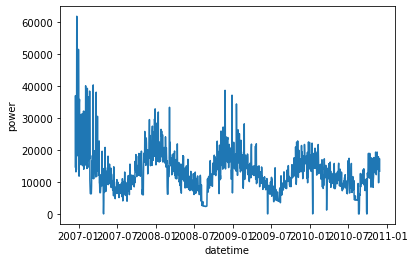

In [48]:
import seaborn as sns

sns.lineplot(x='datetime', y='power', data=data['power'].resample('D').sum().reset_index())

## Creating helper functions
Instead of changing our code every time, we can create a function that will return the plot(s) that we need. In addtion, creating a function allows you to test your code which a good software engineering practice. For more information on functions, see this [link](https://www.tutorialspoint.com/python/python_functions.htm). Write a function that can do the following:
- The function can take in a dataframe, one or more column names, the aggregation level and one or more aggregation metrics (for instance mean or sum). 
- The function should output the graph

<AxesSubplot:xlabel='datetime'>

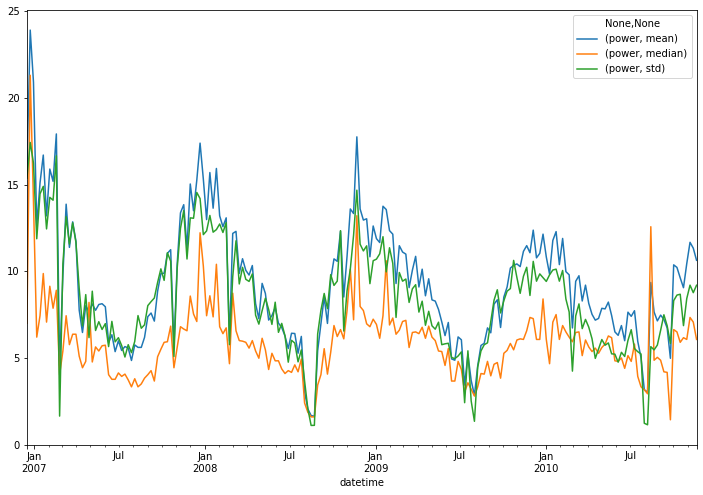

In [85]:
# Function and graph
def plot_timeseries(data, columns: list, period: str, metrics: list, size: tuple):
    return data[columns].resample(period).agg(metrics).plot(figsize=size)
                                                            
plot_timeseries(data, columns=['power'], period='7D', metrics=['mean', 'median', 'std'], size=(12,8))

In [ ]:
# Add your answers here, feel free to add more cells!

---

# Assignment 1:
Now that you've seen how to wrangle the data and create some plots, it's time to find the answer to the following questions:
- Q1: Find the month with the most power consumption
- Q2: Find the top three weeks with the most power consumption
- Q3: What week had the largest difference between what was consumed at the most and the least? 
- Q4: Can you identify periods where there was less than 5000 power consumption per day for at least five consecutive days or more? You might need a few steps to figure this one out.
        

In [37]:
# Q1: Find the month with the most energy consumption, do this programmatically. Verify your answer with a plot.
data['power'].resample('M').sum().idxmin()

Timestamp('2008-08-31 00:00:00', freq='M')

In [36]:
# Q2: Change the index to a weekly period and get the top three weeks with the largest power consumption
data.set_index(data.index.to_period('W'))['power'].resample('1W').sum().nlargest(3)

datetime
2006-12-25/2006-12-31    224839.966667
2007-12-24/2007-12-30    184435.300000
2006-12-18/2006-12-24    181297.466667
Freq: W-SUN, Name: power, dtype: float64

In [35]:
# Q3: Subtract two aggregations
min_max = (
    data.set_index(data.index.to_period('W'))['power']
    .resample('1W')
    .agg(['min', 'max'])
)

(min_max['min'] - min_max['max']).nsmallest(3)

datetime
2006-12-18/2006-12-24   -123.800000
2007-02-12/2007-02-18   -120.100000
2009-03-02/2009-03-08   -119.133333
Freq: W-SUN, dtype: float64

In [77]:
data

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime,power
datetime,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,52.266667
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,72.333333
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,70.566667
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,71.800000
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,43.100000
...,...,...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0,2010-11-26 20:58:00,15.766667
2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0,2010-11-26 20:59:00,15.733333
2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0,2010-11-26 21:00:00,15.633333


In [83]:
# Q4: Use the principal of sessionization
( 
    data[['power']]
    .resample('D').sum()
    .assign(low = lambda df: df['power'] < 5000)
    .assign(break_point = lambda df: df['low'] != df['low'].shift(1))
    .assign(session=lambda df: df['break_point'].cumsum())
    .reset_index() # get index as column
    .groupby('session')
    .agg(
        holiday=('low', 'all'), 
        session_length=('session', 'count'),
        start_date=('datetime', 'min'),
        end_date=('datetime', 'max')
    )
    .loc[lambda df: ((df.holiday == 1) & (df.session_length >= 5))]
)

,holiday,session_length,start_date,end_date
session,,,,
10,True,25,2008-08-06,2008-08-30
20,True,8,2009-08-01,2009-08-08
22,True,5,2010-07-29,2010-08-02
24,True,11,2010-08-04,2010-08-14


In [89]:
( 
    data[['power']].resample('D').sum()
     .assign(low = lambda df: df['power'] < 5000)
    .assign(break_point = lambda df: df['low'] != df['low'].shift(1))
    .assign(session=lambda df: df['break_point'].cumsum())
)

,power,low,break_point,session
datetime,,,,
2006-12-16,14680.933333,False,True,1
2006-12-17,36946.666667,False,False,1
2006-12-18,19028.433333,False,False,1
2006-12-19,13131.900000,False,False,1
2006-12-20,20384.800000,False,False,1
...,...,...,...,...
2010-11-22,16924.600000,False,False,27
2010-11-23,16352.266667,False,False,27
2010-11-24,13769.466667,False,False,27


---

# Storage
In this last step, you're going to store the result of your dataset in `parquet` format. 
- What does this format do? What is the benefit of using this?
- You'll need the data in the next exercise so make sure to store it 

In [51]:
!pip install fastparquet

Processing /Users/jelmer/Library/Caches/pip/wheels/9d/47/83/e3d8de6f492f914d7e02abf5e69dc98b9c8803bc93e6f3c335/fastparquet-0.8.0-cp38-cp38-macosx_10_9_x86_64.whl
  Using cached cramjam-2.5.0-cp38-cp38-macosx_10_9_x86_64.macosx_11_0_arm64.macosx_10_9_universal2.whl (2.7 MB)


In [53]:
cols = ['power']
data[cols].resample('D').sum().to_parquet('data/ex_1.parquet')

---